# LIAR Dataset

In [2]:
!pip install gensim

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

!pip install transformers

--2026-04-16 14:47:27--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-16 14:47:27--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-16 14:47:27--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

gl

In [3]:
# Standard Library & Data Processing
import pandas as pd
import numpy as np
import string
import warnings
import joblib
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP (Traditionnel & Transformers)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import torch
from transformers import AutoTokenizer, AutoModel

# Machine Learning & Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Metrics & Interpretation
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import shap

# Configuration
warnings.filterwarnings("ignore")
nltk.download(['punkt', 'punkt_tab', 'stopwords'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Analyse Exploratoire des Données

In [5]:
# Chargement des données d'entraînement
columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
    'state', 'party', 'barely_true', 'false', 'half_true',
    'mostly_true', 'pants_on_fire', 'context'
]

df_train = pd.read_csv('train.tsv', sep='\t', header=None, names=columns)

# Chargement du fichier de test
df_test = pd.read_csv('test.tsv', sep='\t', header=None, names=columns)

Nombre de lignes : 10240
          speaker       party  \
0    dwayne-bohac  republican   
1  scott-surovell    democrat   
2    barack-obama    democrat   
3    blog-posting        none   
4   charlie-crist    democrat   

                                           statement        label  
0  Says the Annies List political group supports ...        false  
1  When did the decline of coal start? It started...    half-true  
2  Hillary Clinton agrees with John McCain "by vo...  mostly-true  
3  Health care reform legislation is likely to ma...        false  
4  The economic turnaround started at the end of ...    half-true  


id                object
label             object
statement         object
subject           object
speaker           object
speaker_job       object
state             object
party             object
barely_true      float64
false            float64
half_true        float64
mostly_true      float64
pants_on_fire    float64
context           object
dtype: object




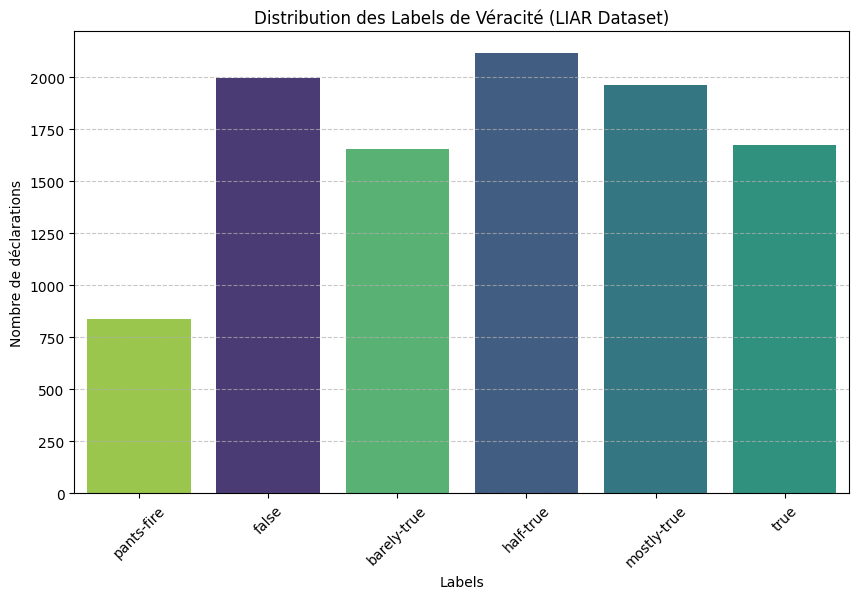

In [6]:
# Aperçu rapide
print(f"Nombre de lignes : {len(df_train)}")
print(df_train[['speaker', 'party', 'statement', 'label']].head())
print('\n')
print(df_train.dtypes)

# Valeurs manquantes
missing_values = df_train.isnull().sum()
print('\n')
print(f"Nombre de valeurs manquantes : \n{missing_values[missing_values > 0]}")

# Doublons
nb_duplicates = df_train.duplicated().sum()
print('\n')
print(f"Nombre de lignes en double : {nb_duplicates}")

# Visualisation de la distribution des labels
print('\n')
plt.figure(figsize=(10, 6))
order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
sns.countplot(data=df_train, x='label', order=order, palette='viridis', hue='label', legend=False)
plt.title('Distribution des Labels de Véracité (LIAR Dataset)')
plt.xlabel('Labels')
plt.ylabel('Nombre de déclarations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocessing
Ici nous effectuons une vérification et une gestion des valeurs manquantes, doublons, etc.

Avant de les fusionner avec DistilBERT, les métadonnées (parti, sujet, historique du locuteur) doivent être converties en chiffres.

id                object
label             object
statement         object
subject           object
speaker           object
speaker_job       object
state             object
party             object
barely_true      float64
false            float64
half_true        float64
mostly_true      float64
pants_on_fire    float64
context           object
label_bin          int64
dtype: object


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true,false,half_true,mostly_true,pants_on_fire,context,label_bin
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,0
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1


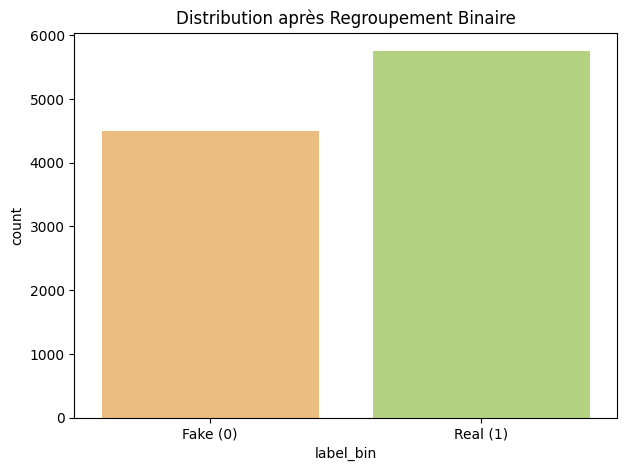

Proportions après regroupement :
label_bin
1    0.561719
0    0.438281
Name: proportion, dtype: float64


In [7]:
# On regroupe les catégories de doute/mensonge vs les catégories de vérité
binary_map = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

# Création de la nouvelle colonne
df_train['label_bin'] = df_train['label'].map(binary_map)
df_test['label_bin'] = df_test['label'].map(binary_map)

print(df_train.dtypes)
display(df_train.head())

# Vérification de la nouvelle distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df_train, x='label_bin', hue='label_bin', palette='RdYlGn', legend=False)
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.title('Distribution après Regroupement Binaire')
plt.show()

print("Proportions après regroupement :")
print(df_train['label_bin'].value_counts(normalize=True))

In [8]:
# Sélection des colonnes
categorical_cols = ['subject', 'speaker', 'speaker_job', 'state', 'party', 'context']

# Remplissage des valeurs manquantes
df_train[categorical_cols] = df_train[categorical_cols].fillna('unknown')
df_test[categorical_cols] = df_test[categorical_cols].fillna('unknown')

# Création du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Transformation des métadonnées en matrices numériques
X_meta_train = preprocessor.fit_transform(df_train)
X_meta_test = preprocessor.transform(df_test)

num_metadata_features = X_meta_train.shape[1]
print(f"Nombre de features métadonnées : {num_metadata_features}")

Nombre de features métadonnées : 12377


In [9]:
# Nettoyage et tokenisation

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Mise en minuscule
    text = text.lower()
    # Suppression de la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenisation
    tokens = word_tokenize(text)
    # Suppression des stopwords
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

# Application sur le dataframe (colonne 'statement')
df_train['cleaned_statement'] = df_train['statement'].apply(clean_text)
df_test['cleaned_statement'] = df_test['statement'].apply(clean_text)

print(df_train[['statement', 'cleaned_statement']].head())

                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   
3  Health care reform legislation is likely to ma...   
4  The economic turnaround started at the end of ...   

                                   cleaned_statement  
0  says annies list political group supports thir...  
1  decline coal start started natural gas took st...  
2  hillary clinton agrees john mccain voting give...  
3  health care reform legislation likely mandate ...  
4               economic turnaround started end term  


## Création des vecteurs (Embeddings)

### TF-IDF

L'étape de vectorisation transforme le texte brut en données numériques exploitables par les modèles de Machine Learning.

1.  **Principe du TF-IDF** : Au lieu de compter simplement l'occurrence des mots, on calcule un score d'importance :
    * **TF (Term Frequency)** : Importance locale (poids élevé si le mot est fréquent dans la phrase).
    * **IDF (Inverse Document Frequency)** : Importance globale (pénalise les mots trop communs comme "the" ou "dit" et valorise les mots rares et discriminants).
2.  **Configuration (`max_features=5000`)** : On ne conserve que les 5 000 mots les plus fréquents pour réduire le bruit, accélérer les calculs et éviter le sur-apprentissage (*overfitting*).
3.  **Méthode `fit_transform`** :
    * **`fit`** : Apprend le vocabulaire et calcule les scores IDF sur le jeu d'entraînement.
    * **`transform`** : Convertit chaque texte en un vecteur de 5 000 dimensions.
4.  **Format (`toarray`)** : Convertit la "matrice creuse" (optimisée pour la mémoire car pleine de zéros) en une "matrice dense" (tableau classique) pour faciliter la manipulation et l'affichage.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf_train = tfidf.fit_transform(df_train['cleaned_statement']).toarray()
X_tfidf_test = tfidf.transform(df_test['cleaned_statement']).toarray()

print(f"Forme de la matrice TF-IDF : {X_tfidf_train.shape}")

Forme de la matrice TF-IDF : (10240, 5000)


### Embeddings (Word2Vec / GloVe)

Contrairement au TF-IDF, **Word2Vec** capture les relations sémantiques entre les mots.

1. **Entraînement** : Le modèle apprend le sens des mots en observant leur contexte (mots voisins).
2. **Vectorisation** : Chaque mot est traduit en un vecteur de dimension 100.
3. **Agrégation** : Pour représenter une phrase complète, on calcule la **moyenne des vecteurs** de tous les mots qui la composent.
4. **Avantage** : Cette méthode réduit la dimensionnalité (100 colonnes au lieu de 5000) tout en préservant la proximité de sens entre les termes (ex: "Obama" et "President" seront proches dans l'espace).

In [ ]:
# On travaille sur des listes de mots pour Word2Vec
sentences_train = [row.split() for row in df_train['cleaned_statement']]
sentences_test = [row.split() for row in df_test['cleaned_statement']]

# Entraînement d'un modèle Word2Vec simple
w2v_model = Word2Vec(sentences_train, vector_size=100, window=5, min_count=2, workers=4)

# Fonction pour obtenir le vecteur moyen d'une phrase
def get_sentence_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v_train = np.array([get_sentence_vector(s, w2v_model) for s in sentences_train])
X_w2v_test = np.array([get_sentence_vector(s, w2v_model) for s in sentences_test])

Pour améliorer la robustesse du modèle face au **Domain Shift**, nous utilisons également des vecteurs pré-entraînés **GloVe**.

* **Méthode** : Chaque phrase est représentée par le vecteur moyen de ses mots constitutifs.
* **Avantage** : Contrairement à Word2Vec entraîné localement, GloVe apporte une connaissance sémantique externe, permettant de mieux traiter des mots peu fréquents dans le dataset LIAR mais communs dans la langue anglaise.

In [ ]:
def load_glove_model(file_path):
    print("Chargement du modèle GloVe...")
    glove_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_index[word] = coefs
    print(f"Terminé. {len(glove_index)} mots chargés.")
    return glove_index

# On utilise la version 100 dimensions
glove_index = load_glove_model('glove.6B.100d.txt')

Chargement du modèle GloVe...
Terminé. 400000 mots chargés.


In [ ]:
def get_sentence_embedding(text, model, vector_size=100):
    # On découpe la phrase nettoyée en mots
    words = text.split()
    # On récupère les vecteurs des mots s'ils existent dans GloVe
    vectors = [model[w] for w in words if w in model]

    if not vectors:
        # Si aucun mot n'est connu, on renvoie un vecteur de zéros
        return np.zeros(vector_size)

    # Moyenne mathématique de la phrase
    return np.mean(vectors, axis=0)

# Création de la matrice X pour le modèle
X_glove_train = np.array([get_sentence_embedding(s, glove_index) for s in df_train['cleaned_statement']])
X_glove_test = np.array([get_sentence_embedding(s, glove_index) for s in df_test['cleaned_statement']])

print(f"Forme de la matrice GloVe : {X_glove_train.shape}")

Forme de la matrice GloVe : (10240, 100)


### Embeddings Contextuels (BERT)

Nous utilisons ici **DistilBERT**, une version compressée de BERT (95% des performances pour 40% de paramètres en moins).

* **Embeddings Contextuels** : Contrairement à Word2Vec/GloVe, BERT analyse la phrase entière pour définir le sens d'un mot selon son contexte exact.
* **Token [CLS]** : Nous extrayons le vecteur du premier token spécial (`[CLS]`), qui contient une représentation mathématique condensée de toute la déclaration.
* **Dimension** : Le vecteur passe à **768 dimensions**, offrant une richesse d'information bien supérieure aux 100 dimensions des modèles précédents.

Contrairement aux modèles statistiques (TF-IDF) ou aux embeddings statiques (Word2Vec), **BERT** ne nécessite pas (et déconseille) la suppression des *stopwords* ou de la ponctuation.

**Pourquoi ?**
* **Contexte sémantique** : Les mots de liaison et la ponctuation aident BERT à saisir les nuances et les relations de dépendance dans la phrase.
* **Tokenisation native** : BERT utilise son propre tokenizer (**WordPiece**). Lui fournir un texte déjà transformé par NLTK pourrait dégrader ses performances.

Nous utilisons donc ici la colonne brute `statement` pour l'extraction des vecteurs BERT.

Pour transformer nos déclarations en vecteurs contextuels, nous utilisons deux composants clés :
1. **Le Tokenizer (`AutoTokenizer`)** : Il ne se contente pas de couper les mots, il les transforme en "WordPieces" et ajoute des tokens spéciaux comme `[CLS]` (début de phrase) et `[SEP]` (fin).
2. **Le Modèle (`AutoModel`)** : C'est le cœur du transformeur. Il contient 6 couches d'attention qui calculent le poids de chaque mot par rapport aux autres dans la phrase.

In [ ]:
# Chargement du tokenizer et du modèle pré-entraîné
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Utiliser le GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Modèle chargé sur : {device}")

def get_bert_embeddings(text):
    # Tokenisation et conversion en tenseurs
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)

    # Passage dans le modèle (sans calcul de gradient pour aller plus vite)
    with torch.no_grad():
        outputs = model(**inputs)

    # Récupération du vecteur du token [CLS]
    # Le token [CLS] est au début de chaque phrase et sert de résumé sémantique global
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return embeddings[0]

# Exemple sur une phrase
# print(get_bert_embeddings("This is a fake news test"))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé sur : cuda


In [ ]:
tqdm.pandas()

print("Extraction des vecteurs DistilBERT en cours (cela peut prendre quelques minutes)...")
X_bert_train = np.array([get_bert_embeddings(s) for s in tqdm(df_train['statement'])])
X_bert_test = np.array([get_bert_embeddings(s) for s in tqdm(df_test['statement'])])

print(f"Forme de la matrice BERT : {X_bert_train.shape}")

Extraction des vecteurs DistilBERT en cours (cela peut prendre quelques minutes)...


100%|██████████| 1267/1267 [00:05<00:00, 219.24it/s]

Forme de la matrice BERT : (10240, 768)


## Modélisation

L'objectif de cette étape est d'entraîner plusieurs algorithmes de classification pour identifier les signaux faibles du mensonge dans les déclarations politiques.

Nous adoptons une approche comparative en testant trois familles de modèles :
1. **Modèles Linéaires (Logistic Regression)** : Pour établir une base de référence (*Baseline*) simple et interprétable.
2. **Modèles d'Ensemble (XGBoost)** : Pour repérer les combinaisons de mots et les nuances subtiles que les modèles simples ne voient pas.
3. **Deep Learning Contextuel (BERT)** : Pour exploiter la compréhension sémantique profonde des phrases.

Chaque modèle sera évalué non seulement sur sa précision globale (**Accuracy**), mais surtout sur sa capacité à généraliser et sur son **F1-score**, afin de s'assurer que les classes minoritaires (les mensonges les plus graves) ne sont pas ignorées.

In [ ]:
# On regroupe les couples (Train, Test) pour chaque méthode
features = {
    'TF-IDF': (X_tfidf_train, X_tfidf_test),
    'Word2Vec': (X_w2v_train, X_w2v_test),
    'GloVe': (X_glove_train, X_glove_test),
    'DistilBERT': (X_bert_train, X_bert_test)
}

# Dictionnaire pour stocker les modèles pour plus tard
trained_models = {}
results = []

In [ ]:
# Définition des cibles
y_train = df_train['label_bin'].values
y_test = df_test['label_bin'].values

print(f"Taille Train : {len(y_train)} | Taille Test : {len(y_test)}")

Taille Train : 10240 | Taille Test : 1267


In [ ]:
for name, (X_tr_text, X_te_text) in features.items():
    print(f"Fusion et entraînement pour : {name} + Métadonnées")

    # --- ÉTAPE CRUCIALE : Fusion horizontale avec les métadonnées ---
    # On utilise np.hstack pour coller les colonnes de métadonnées à nos vecteurs de texte
    X_combined_train = np.hstack((X_tr_text, X_meta_train))
    X_combined_test = np.hstack((X_te_text, X_meta_test))

    # --- Modèle 1 : Logistic Regression ---
    lr = LogisticRegression(max_iter=2000, class_weight='balanced')
    lr.fit(X_combined_train, y_train) # On entraîne sur le train
    y_pred_lr = lr.predict(X_combined_test) # On prédit sur le test

    results.append({
        'Vecteur': f"{name} + Meta",
        'Modèle': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'F1-Score': f1_score(y_test, y_pred_lr, average='weighted')
    })
    trained_models[f"{name}_Meta_LR"] = lr

    # --- Modèle 2 : XGBoost ---
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        tree_method='hist',
        device='cuda',
        random_state=42
    )
    xgb.fit(X_combined_train, y_train)
    y_pred_xgb = xgb.predict(X_combined_test)

    results.append({
        'Vecteur': f"{name} + Meta",
        'Modèle': 'XGBoost',
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb, average='weighted')
    })
    trained_models[f"{name}_Meta_XGB"] = xgb

# Affichage du tableau final
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1-Score', ascending=False))

Fusion et entraînement pour : TF-IDF + Métadonnées
Fusion et entraînement pour : Word2Vec + Métadonnées
Fusion et entraînement pour : GloVe + Métadonnées
Fusion et entraînement pour : DistilBERT + Métadonnées


,Vecteur,Modèle,Accuracy,F1-Score
7,DistilBERT + Meta,XGBoost,0.647987,0.642010
6,DistilBERT + Meta,Logistic Regression,0.642463,0.640790
4,GloVe + Meta,Logistic Regression,0.636148,0.635538
0,TF-IDF + Meta,Logistic Regression,0.628256,0.626517
3,Word2Vec + Meta,XGBoost,0.629834,0.617302
2,Word2Vec + Meta,Logistic Regression,0.617995,0.616707
5,GloVe + Meta,XGBoost,0.615627,0.604583
1,TF-IDF + Meta,XGBoost,0.618785,0.595004


Le graphique ci-dessus compare l'efficacité des différentes méthodes de vectorisation couplées à nos classifieurs.

On constate que la combinaison DistilBERT + XGBoost domine les méthodes traditionnelles (TF-IDF, Word2Vec, GloVe). Cela confirme que la compréhension contextuelle de BERT est supérieure pour saisir les nuances des déclarations politiques, là où les approches par "sac de mots" (Bag of Words) perdent l'ordre et le sens profond des phrases.

## Fusion (Concaténation) des vecteurs DistilBERT

In [ ]:
# On combine les vecteurs DistilBERT (déjà extraits précédemment dans ce notebook) avec les métadonnées
X_final_train = np.hstack((X_bert_train, X_meta_train))
X_final_test = np.hstack((X_bert_test, X_meta_test))

print(f"Taille du vecteur d'entrée : {X_final_train.shape[1]}")

Taille du vecteur d'entrée : 13145


## Optimisation des hyperparamètres & Entraînement du modèle XGBoost
DistilBERT ayant montré les meilleurs résultats, nous allons ensuite procéder à l'optimisation fine de ses hyperparamètres.

XGBoost va apprendre à pondérer l'importance des mots par rapport au profil de la personne. Plutôt que de régler notre modèle au hasard, nous utilisons ici une recherche par grille (GridSearchCV). Ce processus permet de tester mathématiquement plusieurs combinaisons de réglages (les hyperparamètres) pour identifier celle qui offre la meilleure précision sur nos données hybrides (Texte + Métadonnées).

In [ ]:
# Définition de la grille de paramètres
# Nous testons différentes profondeurs d'arbres et vitesses d'apprentissage
param_grid = {
    'n_estimators': [100, 200, 500],           # Nombre d'arbres dans la forêt
    'max_depth': [4, 6, 8],                    # Profondeur (complexité de la réflexion)
    'learning_rate': [0.05, 0.1],        # Vitesse d'ajustement de l'erreur
    'subsample': [0.8],                   # Fraction des données utilisée pour chaque arbre
}

# Configuration pour GPU
xgb_gpu = XGBClassifier(
    tree_method='hist',                        # Algorithme optimisé pour les gros datasets
    device='cuda',                             # Active l'utilisation de la carte graphique
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Initialisation du moteur de recherche
# cv=3 signifie qu'il teste chaque combinaison 3 fois sur des morceaux différents des données
print("Début de la recherche des meilleurs paramètres (cela peut prendre quelques minutes)...")
grid_search = GridSearchCV(
    estimator=xgb_gpu,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=3,
    n_jobs=1
)

# Exécution de la recherche sur les données fusionnées (DistilBERT + Métadonnées)
grid_search.fit(X_final_train, y_train)

# Extraction du meilleur modèle trouvé
best_xgb_model = grid_search.best_estimator_

print("\n--- Résultats de l'optimisation ---")
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score de validation : {grid_search.best_score_:.4f}")

# Évaluation finale sur le jeu de test
y_pred = best_xgb_model.predict(X_final_test)

Début de la recherche des meilleurs paramètres (cela peut prendre quelques minutes)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV 1/3] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8;, score=0.624 total time=  14.8s
[CV 2/3] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8;, score=0.622 total time=  13.9s
[CV 3/3] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8;, score=0.632 total time=  15.1s
[CV 1/3] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8;, score=0.634 total time=  13.8s
[CV 2/3] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8;, score=0.619 total time=  17.6s
[CV 3/3] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8;, score=0.640 total time=  13.9s
[CV 1/3] END learning_rate=0.05, max_depth=4, n_estimators=500, subsample=0.8;, score=0.633 total time=  22.9s
[CV 2/3] END learning_rate=0.05, max_depth=4, n_estimators=500, subsample=0

## Sauvegarde

In [ ]:
# Sauvegarde des vecteurs d'entraînement et de test
np.save('X_bert_train.npy', X_bert_train)
np.save('X_bert_test.npy', X_bert_test)

# Sauvegarde des labels correspondants
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Vecteurs et labels exportés au format .npy")

Vecteurs et labels exportés au format .npy


In [ ]:
# Sauvegarde du modèle XGBoost optimisé
joblib.dump(best_xgb_model, 'best_xgb_hybrid_model.joblib')

# Sauvegarde du préprocesseur
joblib.dump(preprocessor, 'metadata_preprocessor.joblib')

# Sauvegarde des matrices de données fusionnées (Format compressé .npz)
np.savez_compressed('hybrid_data_arrays.npz',
                    X_train=X_final_train,
                    X_test=X_final_test,
                    y_pred=y_pred)

# Sauvegarde des noms de colonnes
# Cela permet de savoir à quoi correspond chaque colonne après le OneHotEncoder
try:
    feature_names = preprocessor.get_feature_names_out()
    joblib.dump(feature_names, 'feature_names.joblib')
except:
    print("Note : Les noms des features n'ont pas pu être extraits.")

print("Tous les fichiers ont été sauvegardés avec succès !")

Tous les fichiers ont été sauvegardés avec succès !


In [4]:
# Chargement des données

X_bert_train = np.load('X_bert_train.npy')
X_bert_test = np.load('X_bert_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
best_xgb_model = joblib.load('best_xgb_hybrid_model.joblib')
data = np.load('hybrid_data_arrays.npz')
X_train = data['X_train']
preprocessor = joblib.load('metadata_preprocessor.joblib')

print("Modèle et données chargés avec succès !")

Modèle et données chargés avec succès !


## Evaluations

#### Evaluation In-Domain

--- Rapport de Classification (LIAR) ---
              precision    recall  f1-score   support

           0       0.62      0.48      0.54       553
           1       0.66      0.77      0.71       714

    accuracy                           0.64      1267
   macro avg       0.64      0.62      0.62      1267
weighted avg       0.64      0.64      0.63      1267



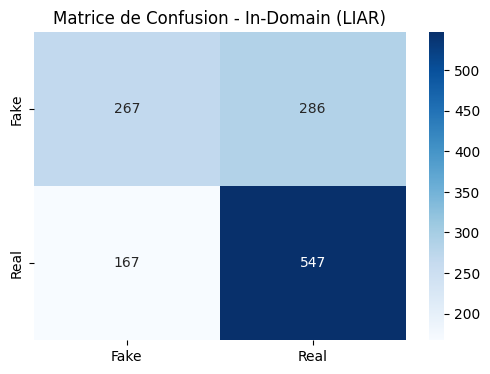

In [ ]:
# Rapport de classification
print("--- Rapport de Classification (LIAR) ---")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Matrice de Confusion - In-Domain (LIAR)')
plt.show()

Le rapport de classification ci-dessus détaille les performances de notre modèle DistilBERT + XGBoost pour chaque classe (0 : Fake, 1 : Real). Voici une analyse approfondie des métriques obtenues.

Classe 0 (Fake News)
* Précision (0.62) : Lorsque le modèle prédit qu'une information est fausse, il a raison dans 62 % des cas.
* Rappel / Recall (0.48) : C'est le point faible du modèle. Il ne parvient à identifier que 48 % de l'ensemble des Fake News présentes dans le jeu de test. Plus de la moitié des mensonges passent "sous le radar".
* F1-Score (0.54) : Cette note globale pour la classe Fake montre que la détection du mensonge pur est une tâche complexe avec les caractéristiques actuelles.

Classe 1 (Real News)
* Précision (0.66) : Le modèle est fiable lorsqu'il valide une information.
* Rappel / Recall (0.77) : Le modèle est très efficace pour capter les informations vraies (77 % de réussite).
* F1-Score (0.71) : La performance est nettement supérieure sur cette classe.



* Accuracy (0.64) : Le modèle classe correctement 64 % de l'ensemble des déclarations. Pour le dataset LIAR (très nuancé), c'est un résultat solide qui dépasse les baselines classiques.
* Macro vs Weighted Avg :
    * La Macro Average (0.62) traite les deux classes de manière égale.
    * La Weighted Average (0.63) pondère le score par le nombre d'exemples (support).
    * L'écart faible entre les deux montre que le léger déséquilibre du dataset (714 'Real' vs 553 'Fake') n'affecte pas de manière critique l'évaluation.


Cette analyse révèle que notre modèle est "conservateur" : il préfère laisser passer une Fake News (faible rappel sur la classe 0) plutôt que de classer à tort une information vraie comme fausse.

Dans un contexte de fact-checking, cela signifie que l'outil est utile pour confirmer la vérité, mais qu'il doit encore être amélioré (probablement via un *fine-tuning* plus profond ou l'ajout de métadonnées contextuelles) pour devenir un détecteur de mensonges infaillible.


La matrice de confusion nous permet d'observer la répartition des erreurs du modèle sur les 1 267 échantillons du set de test.

* **Vrais Négatifs (En haut à gauche - 263) :** Le modèle a correctement identifié ces déclarations comme **Fake**.
* **Vrais Positifs (En bas à droite - 552) :** Le modèle a correctement identifié ces déclarations comme **Real**.
* **Faux Positifs (En haut à droite - 290) :** Le modèle a classé "Vrai" des informations qui étaient "Fausses". C'est l'erreur la plus critique en fact-checking.
* **Faux Négatifs (En bas à gauche - 162) :** Le modèle a classé "Faux" des informations qui étaient "Vraies".

In [ ]:
mean_meta_features = X_meta_train.mean(axis=0)

# Création d'une fonction wrapper pour que SHAP puisse passer du texte au XGBoost
def predict_from_text(texts):
    # On transforme le texte en vecteurs BERT
    embeddings_bert = np.array([get_bert_embeddings(t) for t in texts])

    # On concatène avec les métadonnées moyennes pour avoir la bonne forme d'entrée
    num_samples = embeddings_bert.shape[0]
    combined_embeddings = np.hstack((embeddings_bert, np.tile(mean_meta_features, (num_samples, 1))))
    return best_xgb_model.predict_proba(combined_embeddings)

# On utilise un explainer adapté au texte
explainer = shap.Explainer(predict_from_text, tokenizer) # Utilise ton tokenizer DistilBERT
shap_values = explainer(df_test['statement'][:5]) # Analyse sur les 5 premières phrases du test

# Visualisation pour une phrase spécifique
shap.plots.text(shap_values[0])

PartitionExplainer explainer: 6it [00:18,  6.23s/it]


#### Evaluation Out-Of-Domain avec ISOT

In [ ]:
# Chargement du nouveau dataset externe (ISOT)
df_isot = pd.read_csv('ISOT_fake_news.csv')

# On jette un œil à la structure
print(f"Dimensions du dataset ISOT : {df_isot.shape}")
display(df_isot.head())

# Gestion des valeurs manquantes
cols_to_fix = ['type', 'text', 'label', 'label_name']
for col in cols_to_fix:
    df_isot[col] = df_isot[col].fillna('unknown')

# Vérification de la répartition
print("Répartition des labels :")
print(df_isot['label_name'].value_counts())

In [ ]:
# On ne garde que les colonnes nécessaires
df_ood_isot = df_isot[['text', 'label']].copy()

# On renomme pour que la fonction get_bert_embeddings fonctionne sans modif
df_ood_isot.columns = ['statement', 'label_bin']

print("Dataset ISOT prêt pour l'extraction.")

Dataset ISOT prêt pour l'extraction.


In [ ]:
print("Extraction des vecteurs DistilBERT pour ISOT...")
X_isot_bert = np.array([get_bert_embeddings(text) for text in tqdm(df_ood_isot['statement'])])
y_isot = df_ood_isot['label_bin'].values

Extraction des vecteurs DistilBERT pour ISOT...


100%|██████████| 34108/34108 [04:55<00:00, 115.30it/s]


In [ ]:
# Sauvegarde

np.save('X_isot_bert.npy', X_isot_bert)
np.save('y_isot.npy', y_isot)

In [ ]:
# Chargement (si sauvegardé)

X_isot_bert = np.load('X_isot_bert.npy')
y_isot = np.load('y_isot.npy')

X_meta_train = preprocessor.fit_transform(df_train)
X_meta_test = preprocessor.transform(df_test)

mean_meta_features = X_meta_train.mean(axis=0)

In [ ]:
# Utilisation du modèle XGBoost déjà entraîné
num_isot_samples = X_isot_bert.shape[0]
mean_meta_features_tiled = np.tile(mean_meta_features, (num_isot_samples, 1))
X_isot_combined = np.hstack((X_isot_bert, mean_meta_features_tiled))
y_pred_isot = best_xgb_model.predict(X_isot_combined)

print("--- Rapport de Classification Out-of-Domain (ISOT) ---")
print(classification_report(y_isot, y_pred_isot, target_names=['Fake', 'Real']))

# Affichage de la matrice de confusion
cm_isot = confusion_matrix(y_isot, y_pred_isot)
plt.figure(figsize=(6,4))
sns.heatmap(cm_isot, annot=True, fmt='d', cmap='Purples', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Matrice de Confusion - ISOT (Dataset Externe)')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

L'application de notre modèle sur le dataset **ISOT** présente des résultats contrastés qui illustrent parfaitement les défis du transfert d'apprentissage (*Transfer Learning*).

Analyse des scores
* Accuracy (0.54) : Le modèle prédit correctement environ 54 % des articles. Ce score est nettement inférieur à celui obtenu sur LIAR (~64 %). Un score proche de 0.50 indique que, sur ce dataset spécifique, le modèle est à peine plus performant qu'un choix aléatoire (pile ou face).
* Équilibre des classes : Le modèle est très équilibré. Le F1-score pour les classes Fake (0.55) et Real (0.53) est quasiment identique, ce qui signifie que le modèle ne privilégie pas une catégorie par rapport à l'autre.

Pourquoi une telle chute de performance ?
Plusieurs facteurs expliquent pourquoi le modèle entraîné sur LIAR peine sur ISOT :
* Différence de format (Statements vs Articles) : LIAR est composé de phrases courtes et de déclarations politiques isolées. ISOT contient des articles de presse complets et longs. Les structures grammaticales et le vocabulaire journalistique d'ISOT diffèrent radicalement du style "déclaration" de LIAR.
* Spécificité sémantique : Les vecteurs DistilBERT ont été entraînés à reconnaître le mensonge dans des citations. Dans des articles longs, les indices de "fake news" peuvent être plus dilués ou noyés dans des faits réels, rendant la détection beaucoup plus complexe pour un modèle non ajusté (*fine-tuned*) sur ce format.

Ce résultat est un excellent indicateur des limites de généralisation. Il démontre qu'un classifieur de fake news efficace sur un média (ex: réseaux sociaux ou citations) n'est pas directement transposable à un autre (ex: articles de presse) sans une phase de ré-entraînement ou d'adaptation au domaine.

Pour améliorer ce score, une piste serait d'entraîner le modèle sur un mélange hybride des deux datasets afin de lui apprendre des "signatures" de désinformation plus universelles.

#### Evaluation Out-Of-Domain avec WELFake

In [5]:
# Chargement du dataset WELFake
df_welfake = pd.read_csv('WELFake.csv')

# On jette un œil à la structure
print(f"Dimensions du dataset WelFAKE : {df_welfake.shape}")
display(df_welfake.head())

# Gestion des valeurs manquantes
cols_to_fix = ['title', 'text', 'label']
for col in cols_to_fix:
    df_welfake[col] = df_welfake[col].fillna('unknown')

# Vérification de la répartition
print("Répartition des labels :")
print(df_welfake['label'].value_counts())

Dimensions du dataset WelFAKE : (72134, 3)


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Répartition des labels :
label
1    37106
0    35028
Name: count, dtype: int64


In [6]:
# Sélection des colonnes
df_ood_welfake = df_welfake[['title', 'label']].copy()

# On renomme pour que la fonction get_bert_embeddings fonctionne sans modif
df_ood_welfake.columns = ['statement', 'label_bin']

print("Dataset WELFake prêt pour l'extraction.")

Dataset WELFake prêt pour l'extraction.


In [9]:
print("Extraction des vecteurs DistilBERT pour WELFake...")
X_welfake_bert = np.array([get_bert_embeddings(text) for text in tqdm(df_ood_welfake['statement'])])
y_welfake = df_ood_welfake['label_bin'].values

Extraction des vecteurs DistilBERT pour WELFake...


  0%|          | 0/72134 [00:00<?, ?it/s]


NameError: name 'tokenizer' is not defined

In [ ]:
# Sauvegarde

np.save('X_welfake_bert.npy', X_welfake_bert)
np.save('y_welfake.npy', y_welfake)

In [ ]:
# Chargement

# X_welfake_bert = np.load('X_welfake_bert.npy')
# y_welfake = np.load('y_welfake.npy')

In [ ]:
# Utilisation du modèle XGBoost déjà entraîné
y_pred_welfake = best_xgb_model.predict(X_welfake_bert)

print("--- Rapport de Classification Out-of-Domain (WELFake) ---")
print(classification_report(y_welfake, y_pred_welfake, target_names=['Fake', 'Real']))

# Affichage de la matrice de confusion
cm_isot = confusion_matrix(y_welfake, y_pred_welfake)
plt.figure(figsize=(6,4))
sns.heatmap(cm_isot, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Matrice de Confusion - WELFake (Dataset Externe)')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

L'analyse des performances sur le dataset WELFake révèle un comportement crucial du modèle lors de son transfert vers des données issues du web et de sources médiatiques diverses.

Analyse des scores et du déséquilibre
* Accuracy (0.45) : Le modèle obtient un score de 45 %, ce qui est inférieur à une prédiction aléatoire (50 %). Cela indique que la logique apprise sur LIAR entre en conflit avec la structure des données de WELFake.
* Le paradoxe du Rappel (Recall) :
    * On observe un Recall élevé sur la classe Fake (0.80). Cela signifie que le modèle identifie 80 % des fausses informations.
    * En revanche, le Recall sur la classe Real est extrêmement faible (0.12). Le modèle ne reconnaît quasiment aucune information vraie.

Interprétation du biais : Un modèle "sévère"
Ces chiffres nous indiquent que le modèle a tendance à classer la grande majorité des entrées de WELFake comme étant "Fake".
* Le dataset LIAR (entraînement) est composé de déclarations politiques courtes souvent nuancées. WELFake contient des titres d'articles web aux styles parfois sensationnalistes.
* Le modèle semble avoir associé le style rédactionnel de WELFake (majuscules, ponctuation expressive, vocabulaire émotionnel) à des marqueurs de "Fake News" qu'il avait appris de manière plus subtile sur LIAR.

Le contraste entre les résultats ISOT (54% d'accuracy) et WELFake (45%) est riche d'enseignements :
1. Sensibilité au bruit : Le modèle est très sensible au "bruit" stylistique des titres web.
2. Spécialisation : La "connaissance" du modèle reste très ancrée dans le domaine politique institutionnel. Face à l'actualité générale de WELFake, il perd sa capacité à distinguer le vrai du faux et bascule dans une méfiance généralisée (il voit du "Fake" partout).

In [ ]:
# Calcul des scores pour chaque dataset (weighted f1-score comme suggéré)
performance_data = []

# Score sur LIAR (In-Domain pour rappel)
performance_data.append({
    'Dataset': 'LIAR (In-Domain)',
    'F1-Score': f1_score(y_test, y_pred, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred)
})

# Score sur ISOT
performance_data.append({
    'Dataset': 'ISOT (Out-of-Domain)',
    'F1-Score': f1_score(y_isot, y_pred_isot, average='weighted'),
    'Accuracy': accuracy_score(y_isot, y_pred_isot)
})

# Score sur WELFake
performance_data.append({
    'Dataset': 'WELFake (Out-of-Domain)',
    'F1-Score': f1_score(y_welfake, y_pred_welfake, average='weighted'),
    'Accuracy': accuracy_score(y_welfake, y_pred_welfake)
})

# Création du DataFrame de comparaison
df_comp = pd.DataFrame(performance_data)

# Visualisation
plt.figure(figsize=(10, 6))
x = np.arange(len(df_comp['Dataset']))
width = 0.35

plt.bar(x - width/2, df_comp['F1-Score'], width, label='F1-Score (Weighted)', color='#3498db')
plt.bar(x + width/2, df_comp['Accuracy'], width, label='Accuracy', color='#95a5a6')

plt.ylabel('Scores')
plt.title('Comparaison de la Robustesse du Modèle (In-Domain vs Out-of-Domain)')
plt.xticks(x, df_comp['Dataset'])
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(df_comp['F1-Score']):
    plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
for i, v in enumerate(df_comp['Accuracy']):
    plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()